In [ ]:
# DATA PREPROCESSING AND FEATURE ENGINEERING IN MACHINE LEARNING

# Task-1:Data Exploration ad Preprocessing

## Step-1:Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

## Step-2:Load the Dataset

In [2]:
df=pd.read_csv("adult_with_headers.csv")

## Step-3:Display First Five Rows

In [3]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Step-4:Display Last Five Rows

In [4]:
df.tail()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


## step-5:Shape of Dataset

In [5]:
df.shape

(32561, 15)

## Step-6:Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


## Step-7:Statistical Summary

In [7]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## Step-8:Check Missing Values

In [9]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

## Step-9:Column Names


In [4]:
print(df.columns)

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')


## Step-10:Data types

In [5]:
df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

## Step-11: Handle Missing Values


In [6]:
#Numerical Columns
num_cols = df.select_dtypes(include=np.number).columns

imputer_num = SimpleImputer(strategy='median')

df[num_cols] = imputer_num.fit_transform(df[num_cols])


In [8]:
#Categorical Columns

cat_cols = df.select_dtypes(include='object').columns

imputer_cat = SimpleImputer(strategy='most_frequent')

df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

## Step-12:Identify Numerical Columns

In [9]:
numerical_columns = df.select_dtypes(include=np.number).columns

print(numerical_columns)

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')


## Standard Scaling

In [10]:
scaler = StandardScaler()

df_standard = df.copy()

df_standard[numerical_columns] = scaler.fit_transform(df_standard[numerical_columns])

df_standard.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.030671,State-gov,-1.063611,Bachelors,1.134739,Never-married,Adm-clerical,Not-in-family,White,Male,0.148453,-0.21666,-0.035429,United-States,<=50K
1,0.837109,Self-emp-not-inc,-1.008707,Bachelors,1.134739,Married-civ-spouse,Exec-managerial,Husband,White,Male,-0.145920,-0.21666,-2.222153,United-States,<=50K
2,-0.042642,Private,0.245079,HS-grad,-0.420060,Divorced,Handlers-cleaners,Not-in-family,White,Male,-0.145920,-0.21666,-0.035429,United-States,<=50K
3,1.057047,Private,0.425801,11th,-1.197459,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,-0.145920,-0.21666,-0.035429,United-States,<=50K
4,-0.775768,Private,1.408176,Bachelors,1.134739,Married-civ-spouse,Prof-specialty,Wife,Black,Female,-0.145920,-0.21666,-0.035429,Cuba,<=50K


### Min-Max Scaling

In [11]:
minmax = MinMaxScaler()

df_minmax = df.copy()

df_minmax[numerical_columns] = minmax.fit_transform(df_minmax[numerical_columns])

df_minmax.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.301370,State-gov,0.044302,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.02174,0.0,0.397959,United-States,<=50K
1,0.452055,Self-emp-not-inc,0.048238,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.00000,0.0,0.122449,United-States,<=50K
2,0.287671,Private,0.138113,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.00000,0.0,0.397959,United-States,<=50K
3,0.493151,Private,0.151068,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.00000,0.0,0.397959,United-States,<=50K
4,0.150685,Private,0.221488,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.00000,0.0,0.397959,Cuba,<=50K


### Standard Scaling
Converts data to mean = 0 and standard deviation = 1.
Best for algorithms like Logistic Regression, SVM, KNN, and Neural Networks.


### Min-Max Scaling
Scales values between 0 and 1.
Best for Deep Learning and distance-based algorithms when a fixed range is preferred.


# Task-2:Encoding Techniques:

In [12]:
#Identify Categorical Columns
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')


In [13]:
#Check Number of Unique Categories

for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

workclass: 9 unique values
education: 16 unique values
marital_status: 7 unique values
occupation: 15 unique values
relationship: 6 unique values
race: 5 unique values
sex: 2 unique values
native_country: 42 unique values
income: 2 unique values


In [14]:
#Seperate Columns for One-Hot and Label Encoding

onehot_cols = [col for col in cat_cols if df[col].nunique() < 5]
label_cols = [col for col in cat_cols if df[col].nunique() >= 5]

print("One-Hot Encoding Columns:", onehot_cols)
print("Label Encoding Columns:", label_cols)

One-Hot Encoding Columns: ['sex', 'income']
Label Encoding Columns: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']


In [15]:
#Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=onehot_cols)

df_encoded.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,2174.0,0.0,40.0,United-States,False,True,True,False
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,0.0,0.0,13.0,United-States,False,True,True,False
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,0.0,0.0,40.0,United-States,False,True,True,False
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,0.0,0.0,40.0,United-States,False,True,True,False
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,0.0,0.0,40.0,Cuba,True,False,True,False


In [16]:
#Import Label Encoder
from sklearn.preprocessing import LabelEncoder

In [17]:
#Apply Label Encoding
le = LabelEncoder()

for col in label_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

df_encoded.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,39.0,7,77516.0,9,13.0,4,1,1,4,2174.0,0.0,40.0,39,False,True,True,False
1,50.0,6,83311.0,9,13.0,2,4,0,4,0.0,0.0,13.0,39,False,True,True,False
2,38.0,4,215646.0,11,9.0,0,6,1,4,0.0,0.0,40.0,39,False,True,True,False
3,53.0,4,234721.0,1,7.0,2,6,0,2,0.0,0.0,40.0,39,False,True,True,False
4,28.0,4,338409.0,9,13.0,2,10,5,2,0.0,0.0,40.0,5,True,False,True,False


In [18]:
#Check Data Types After Encoding
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32561 non-null  float64
 1   workclass       32561 non-null  int64  
 2   fnlwgt          32561 non-null  float64
 3   education       32561 non-null  int64  
 4   education_num   32561 non-null  float64
 5   marital_status  32561 non-null  int64  
 6   occupation      32561 non-null  int64  
 7   relationship    32561 non-null  int64  
 8   race            32561 non-null  int64  
 9   capital_gain    32561 non-null  float64
 10  capital_loss    32561 non-null  float64
 11  hours_per_week  32561 non-null  float64
 12  native_country  32561 non-null  int64  
 13  sex_ Female     32561 non-null  bool   
 14  sex_ Male       32561 non-null  bool   
 15  income_ <=50K   32561 non-null  bool   
 16  income_ >50K    32561 non-null  bool   
dtypes: bool(4), float64(6), int64(7

In [19]:
#Verify No Object Columns Left
df_encoded.select_dtypes(include='object').columns

Index([], dtype='object')

# One-Hot Encoding
### Advantages:
Does not create an order between categories.
Suitable for nominal variables.
Improves model performance for many ML algorithms.
### Disadvantages:
Increases the number of columns.
Can make the dataset sparse.


# Label Encoding
### Advantages:
Simple and memory efficient.
Suitable for high-cardinality categorical variables.
Useful for tree-based models.
### Disadvantages:
Introduces an artificial order among categories.
May negatively affect linear and distance-based models.

# Task-3:Feature Engineering

In [20]:
#Create a copy of the Encoded Dataset
df_feature=df_encoded.copy()

In [25]:
#Create New Feature 1(Total Income)
df_feature['total_income'] = df_feature['capital_gain'] + df_feature['capital_loss']

df_feature[['capital_gain','capital_loss','total_income']].head()

,capital_gain,capital_loss,total_income
0,2174.0,0.0,2174.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0


In [23]:
print(df.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


### Explanation:
This feature represents the overall capital income, which may improve model performance.

In [26]:
#Create New Feature 2 (Age Group)
df_feature['age_group'] = pd.cut(
    df_feature['age'],
    bins=[0,25,45,65,100],
    labels=['Young','Adult','Middle_Age','Senior']
)

df_feature[['age','age_group']].head()

,age,age_group
0,39.0,Adult
1,50.0,Middle_Age
2,38.0,Adult
3,53.0,Middle_Age
4,28.0,Adult


### Explanation:
Groups people into age categories.
Age groups often capture patterns better than raw age values.

In [27]:
#Convert New Categorical Feature into Numeric
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_feature['age_group'] = le.fit_transform(df_feature['age_group'])

In [28]:
#Check Skewness of Numerical Columns
df_feature.skew(numeric_only=True)


age                0.558743
workclass         -0.752024
fnlwgt             1.446980
education         -0.934042
education_num     -0.311676
marital_status    -0.013508
occupation         0.114583
relationship       0.786818
race              -2.435386
capital_gain      11.953848
capital_loss       4.594629
hours_per_week     0.227643
native_country    -3.658303
sex_ Female        0.719293
sex_ Male         -0.719293
income_ <=50K     -1.212430
income_ >50K       1.212430
total_income      11.927101
age_group          0.927721
dtype: float64

### Apply Log Transformation
capital_gain is highly skewed in the Adult dataset.

In [30]:
df_feature['capital_gain_log'] = np.log1p(df_feature['capital_gain'])

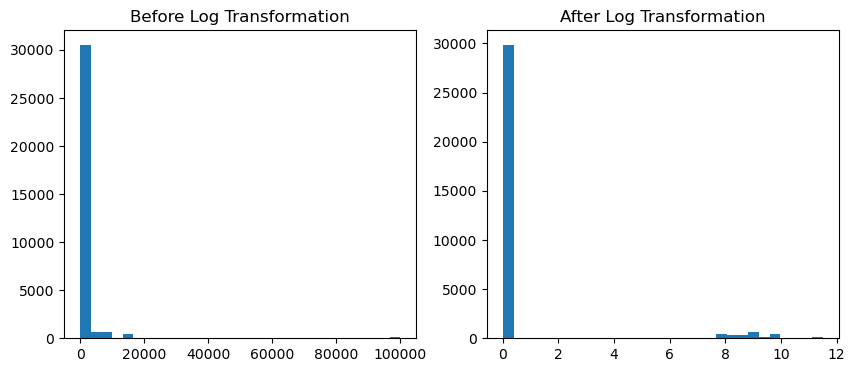

In [32]:
#Compare Before and After Transformation
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df_feature['capital_gain'], bins=30)
plt.title("Before Log Transformation")

plt.subplot(1,2,2)
plt.hist(df_feature['capital_gain_log'], bins=30)
plt.title("After Log Transformation")

plt.show()

In [33]:
#Display Newly Created Features
df_feature[['total_income','age_group','capital_gain_log']].head()

,total_income,age_group,capital_gain_log
0,2174.0,0,7.684784
1,0.0,1,0.000000
2,0.0,0,0.000000
3,0.0,1,0.000000
4,0.0,0,0.000000


## Observation 
Created two new features:
total_income = capital_gain + capital_loss
age_group = grouped age into categories.
Applied Log Transformation on capital_gain to reduce skewness.
These engineered features can improve machine learning model performance.

# Task-4:Feature Selection

In [34]:
#Install PPS 
!pip install ppscore

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for ppscore: filename=ppscore-1.3.1-py2.py3-none-any.whl size=13263 sha256=5bfbad7fc8950825bdf6ef6679e851cd4e2ac571ad5ce00a33a1a5f6c0f965d9
  Stored in directory: c:\users\o.ramya\appdata\local\pip\cache\wheels\b4\95\1f\bfb3b7b3845232909c01caa738277f86d0148164d3a617ad42
Successfully built ppscore


In [35]:
#import Required Libraries
import ppscore as pps
from sklearn.ensemble import IsolationForest

In [36]:
#Detect Outliers Using Isolation Forest
numeric_cols = df_feature.select_dtypes(include=['int64', 'float64']).columns

iso = IsolationForest(contamination=0.05, random_state=42)

df_feature['Outlier'] = iso.fit_predict(df_feature[numeric_cols])

df_feature.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,...,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K,total_income,age_group,capital_gain_log,Outlier
0,39.0,7,77516.0,9,13.0,4,1,1,4,2174.0,...,40.0,39,False,True,True,False,2174.0,0,7.684784,1
1,50.0,6,83311.0,9,13.0,2,4,0,4,0.0,...,13.0,39,False,True,True,False,0.0,1,0.000000,1
2,38.0,4,215646.0,11,9.0,0,6,1,4,0.0,...,40.0,39,False,True,True,False,0.0,0,0.000000,1
3,53.0,4,234721.0,1,7.0,2,6,0,2,0.0,...,40.0,39,False,True,True,False,0.0,1,0.000000,1
4,28.0,4,338409.0,9,13.0,2,10,5,2,0.0,...,40.0,5,True,False,True,False,0.0,0,0.000000,1


In [37]:
#Remove Outliers
df_clean = df_feature[df_feature['Outlier'] == 1]

print("Original Shape:", df_feature.shape)
print("After Removing Outliers:", df_clean.shape)


Original Shape: (32561, 21)
After Removing Outliers: (30933, 21)


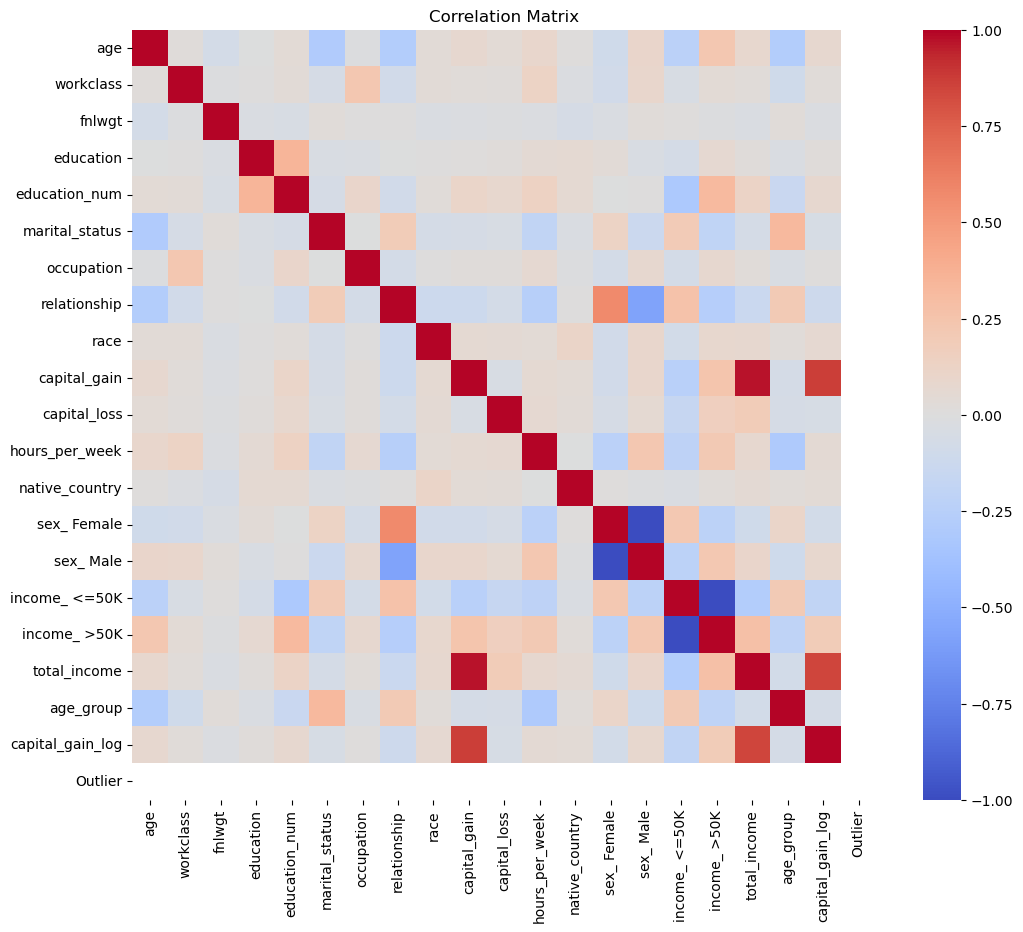

In [38]:
#Correlation Matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(df_clean.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [39]:
#PPS(Predictive Power Score)
pps_matrix=pps.matrix(df_clean)
pps_matrix.head()

,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
0,age,age,1.0,predict_itself,True,None,0.0000,1.000000,None
1,age,workclass,0.0,regression,True,mean absolute error,0.7504,0.875652,DecisionTreeRegressor()
2,age,fnlwgt,0.0,regression,True,mean absolute error,77177.0798,78644.666730,DecisionTreeRegressor()
3,age,education,0.0,regression,True,mean absolute error,2.6710,2.722042,DecisionTreeRegressor()
4,age,education_num,0.0,regression,True,mean absolute error,1.8556,1.883073,DecisionTreeRegressor()


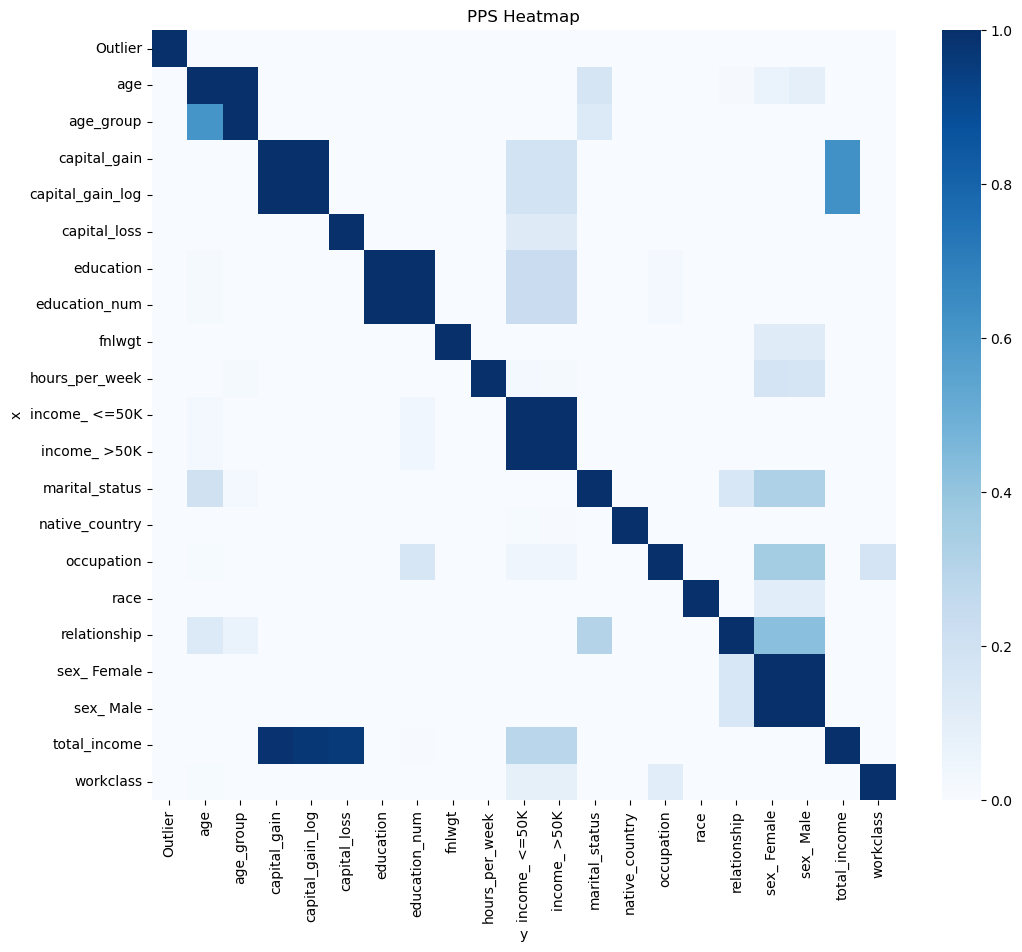

In [40]:
#PPS Heatmap
pps_pivot = pps_matrix.pivot(index='x', columns='y', values='ppscore')

plt.figure(figsize=(12,10))
sns.heatmap(pps_pivot, cmap='Blues')
plt.title("PPS Heatmap")
plt.show()

### Observation
Isolation Forest detected and removed outliers from the dataset.
Removing outliers helps improve model performance and reduces the effect of extreme values.
Correlation Matrix shows only linear relationships.
PPS detects both linear and non-linear relationships, making it more informative in many cases.

### Conclusion:

In this assignment, data preprocessing and feature engineering techniques were successfully applied to the Adult dataset. Missing values were handled, numerical features were scaled using StandardScaler and MinMaxScaler, and categorical variables were encoded using One-Hot Encoding and Label Encoding. New features were created, and log transformation was applied to reduce skewness. Isolation Forest was used to detect and remove outliers, and PPS analysis was compared with the correlation matrix to understand feature relationships. These preprocessing steps improve the quality of data and help build better machine learning models.

### 1. What is Data Preprocessing?
Answer: Data preprocessing is the process of cleaning, transforming, and preparing raw data before training a machine learning model.
### 2. Why is scaling required?
Answer: Scaling ensures that numerical features are on a similar scale, which improves the performance of many machine learning algorithms.
### 3. What is Standard Scaling?
Answer: Standard Scaling transforms data so that it has a mean of 0 and a standard deviation of 1.
## 4. What is Min-Max Scaling?
Answer: Min-Max Scaling transforms data into a range between 0 and 1.
### 5. What is One-Hot Encoding?
Answer: One-Hot Encoding converts categorical variables into multiple binary columns.
### 6. What is Label Encoding?
Answer: Label Encoding assigns a unique integer to each category.
### 7. What is Feature Engineering?
Answer: Feature Engineering is the process of creating new features from existing data to improve model performance.
### 8. Why is Log Transformation used?
Answer: It reduces skewness in numerical data and makes the distribution more suitable for machine learning models.
### 9. What is Isolation Forest?
Answer: Isolation Forest is an algorithm used to detect anomalies or outliers in a dataset.
### 10. What is PPS (Predictive Power Score)?
Answer: PPS measures how well one feature predicts another feature, capturing both linear and non-linear relationships.